# **Intro ML Week 3.1 - DT**
---
**Decision Tree From Scratch**

In [1]:
# Import required libraries.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## **Decision Tree Regressor - Sklearn**
---

In [2]:
# Load the data.
raw_data = {
    "X": np.array(list(range(1, 15))),
    "y": np.array([1, 1.2, 1.4, 1.1, 1.0, 5.5, 6.1, 6.7, 6.4, 6, 5.9, 3, 3.2, 3.1])
}

data = pd.DataFrame(raw_data)
data

,X,y
0,1,1.0
1,2,1.2
2,3,1.4
3,4,1.1
4,5,1.0
5,6,5.5
6,7,6.1
7,8,6.7
8,9,6.4
9,10,6.0


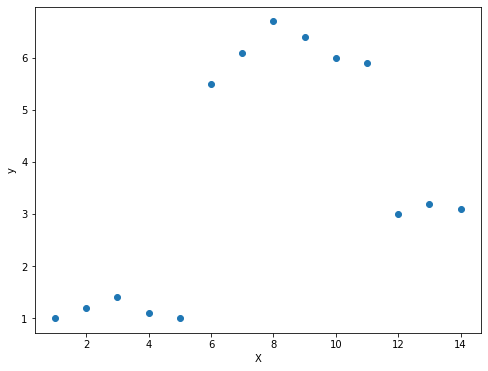

In [3]:
# Plot the data.
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

ax.scatter(data["X"], data["y"])

ax.set_xlabel("X")
ax.set_ylabel("y")
plt.show()

`DecisionTreeRegressor` from scikit-learn.

> Read more: [here](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)

In [4]:
# Import the DecisionTreeRegressor class.
from sklearn.tree import DecisionTreeRegressor

In [5]:
# Convert shape from (14,) to (14,1).
# sklearn only accepts 2-D array.
X = data["X"].values.reshape(-1, 1)
y = data["y"].values.reshape(-1, 1)

In [6]:
X.shape

(14, 1)

In [7]:
# Create object model.
dt_reg = DecisionTreeRegressor()

# Fit the model.
dt_reg.fit(X, y)

DecisionTreeRegressor()

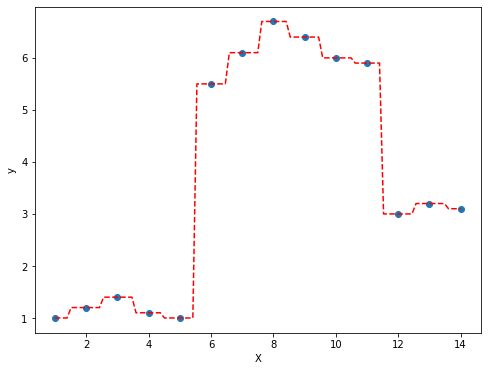

In [8]:
# Plot the prediction results.
X_pred = np.linspace(data["X"].min(), data["X"].max(), 101)
y_pred = dt_reg.predict(X_pred.reshape(-1, 1))

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

ax.scatter(data["X"], data["y"])
ax.plot(X_pred, y_pred, "--r")

ax.set_xlabel("X")
ax.set_ylabel("y")
plt.show()

- We can plot the tree using `plot_tree` function.

> Read more: [here](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html)

In [9]:
# Import the plot_tree function.
from sklearn.tree import plot_tree

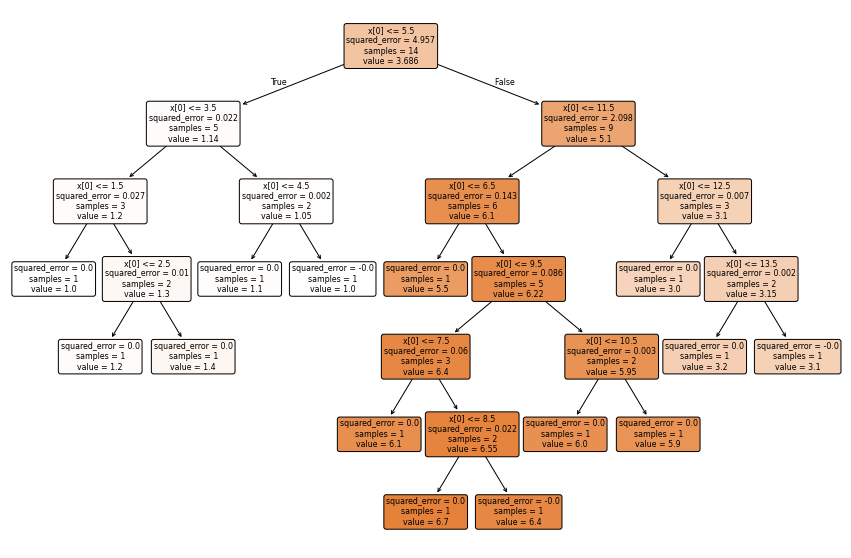

In [10]:
# Plot the decision tree.
plt.figure(figsize=(15, 10))
plot_tree(dt_reg, filled=True, rounded=True)
plt.show()

- Let's do some pruning.
- Tune the `max_depth` = $2$.

In [11]:
# Tree pruning.
dt_reg_pruned = DecisionTreeRegressor(max_depth=2)

# Fit the model.
dt_reg_pruned.fit(X, y)

DecisionTreeRegressor(max_depth=2)

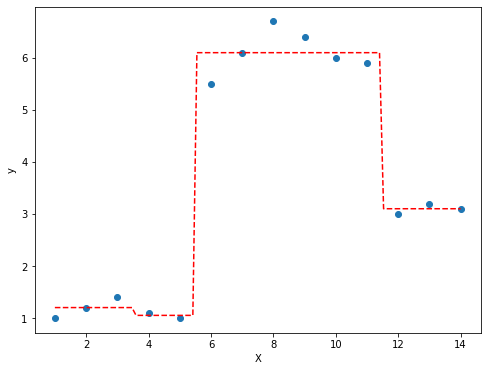

In [12]:
# Plot the prediction results.
X_pred = np.linspace(data["X"].min(), data["X"].max(), 101)
y_pred = dt_reg_pruned.predict(X_pred.reshape(-1, 1))

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

ax.scatter(data["X"], data["y"])
ax.plot(X_pred, y_pred, "--r")

ax.set_xlabel("X")
ax.set_ylabel("y")
plt.show()

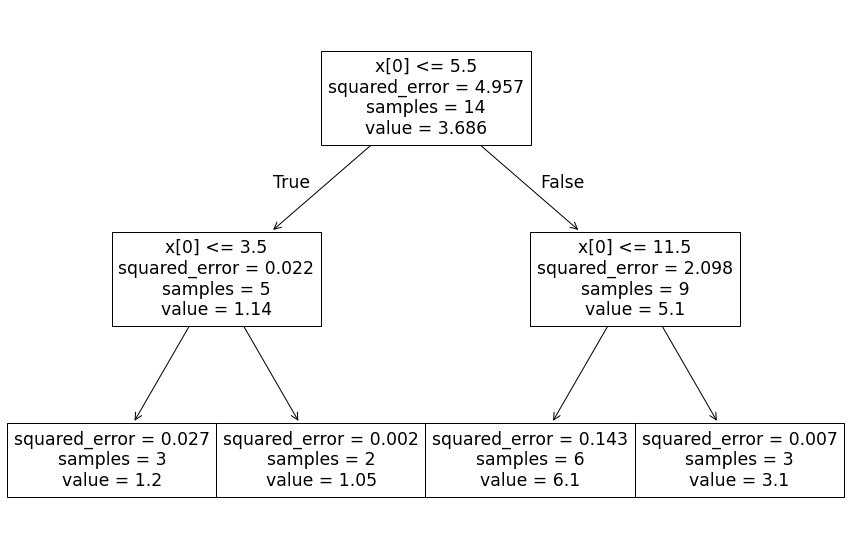

In [13]:
# Plot the pruned tree.
plt.figure(figsize=(15, 10))
plot_tree(dt_reg_pruned)
plt.show()

## **Decision Tree Classifier**
---

### **Decision Tree Classifier From Scratch**
---

#### **1. Define the Calculate Entropy Function**


- Define the `calculate_entropy` function.
- It receives 1 argument: `data`
- It returns the entropy from the set of data.

In [14]:
# Function to calculate entropy.
def calculate_entropy(data):
    """
    Calculate the entropy for DT Classifier.
    """
    # Calculate the proportion.
    proba = data.value_counts(normalize=True)

    # Calculate the entropy.
    entropy = 0
    for p in proba:
        proba_i = p
        entropy += -(proba_i * np.log2(proba_i))

    return entropy

In [15]:
# Test the function.
raw_1 = {
    "target": ["yes", "yes", "yes", "yes", "yes"]
}

set_1 = pd.DataFrame(raw_1)
print(f"The entropy of set_1 : {calculate_entropy(set_1)}")

The entropy of set_1 : 0.0


In [16]:
# Test the function.
raw_2 = {
    "target": ["yes", "yes", "no", "no"]
}

set_2 = pd.DataFrame(raw_2)
print(f"The entropy of set_2 : {calculate_entropy(set_2)}")

The entropy of set_2 : 1.0


#### **Case Study: Play Tennis Prediction**


In [17]:
# Load the data.
FNAME = "3.1-play_tennis.csv"

df_tennis = pd.read_csv(FNAME)
df_tennis.head()

,outlook,temp,humidity,wind,play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


- First we need to find the *best splitting attribute* (feature with highest information gain).

#### **2. Define the Calculate Info Gain Function**


- Define the `calculate_info_gain` function.
- It receives 2 arguments: `data` and `parent`
- It returns the info gain from the set of data.

In [18]:
# Function to calculate information gain.
def calculate_info_gain(data, parent):
    """
    Calculate the information gain for DT Classifier.
    """
    # 1. Calculate the entropy of the parent.
    parent_data = data[[parent, "play"]]
    parent_entropy = calculate_entropy(data = parent_data["play"])

    # 2. Calculate the entropy of the children.
    children = parent_data[parent].unique()
    children_entropy = np.zeros(len(children))
    num_children = np.zeros(len(children))

    for i, child in enumerate(children):
        child_data = parent_data[parent_data[parent] == child]
        child_entropy = calculate_entropy(data = child_data)

        children_entropy[i] = child_entropy
        num_children[i] = len(child_data)

    # 3. Calculate the information gain.
    avg_children_entropy = np.sum(children_entropy * num_children) / len(parent_data)
    info_gain = parent_entropy - avg_children_entropy

    return info_gain

- Define the `get_nodes` function.
- It receives 1 argument: `data`.
- It wraps the `calculate_info_gain` function for all available subset of data.

In [19]:
# Function to calculate info gain on every subset of data.
def get_nodes(data):
    """
    Calculate information gain for every subset of data.
    """
    for col in data.columns:
        if col != "play":
            info_gain_col = calculate_info_gain(data = data,
                                                parent = col)
            print(f"IG for {col} is {info_gain_col:.4f}")

In [20]:
# Test the function.
get_nodes(data = df_tennis)

IG for outlook is 0.2467
IG for temp is 0.0292
IG for humidity is 0.1518
IG for wind is 0.0481


In [21]:
# Check all possible values for outlook column.
df_tennis["outlook"].value_counts()

outlook
Sunny       5
Rain        5
Overcast    4
Name: count, dtype: int64

- We got that `outlook` column has the highest info gain.
- Thus, the `outlook` column will be the root.


- Our current tree:
```
Outlook:
    - Sunny
    - Rain
    - Overcast
```

#### **3. Info Gain for Every Branch**

**Root - Outlook:**

In [22]:
# IG for outlook == Sunny.
data_outlook_sunny = df_tennis[df_tennis["outlook"] == "Sunny"]

get_nodes(data = data_outlook_sunny)

data_outlook_sunny

IG for outlook is 0.0000
IG for temp is 0.5710
IG for humidity is 0.9710
IG for wind is 0.0200


,outlook,temp,humidity,wind,play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
10,Sunny,Mild,Normal,Strong,Yes


In [23]:
# Check all possible values for humidity column.
data_outlook_sunny["humidity"].value_counts()

humidity
High      3
Normal    2
Name: count, dtype: int64

In [24]:
# IG for outlook == Rain.
data_outlook_rain = df_tennis[df_tennis["outlook"] == "Rain"]

get_nodes(data = data_outlook_rain)

data_outlook_rain

IG for outlook is 0.0000
IG for temp is 0.0200
IG for humidity is 0.0200
IG for wind is 0.9710


,outlook,temp,humidity,wind,play
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
9,Rain,Mild,Normal,Weak,Yes
13,Rain,Mild,High,Strong,No


In [25]:
# Check all possible values for wind column.
data_outlook_rain["wind"].value_counts()

wind
Weak      3
Strong    2
Name: count, dtype: int64

In [26]:
# IG for outlook == Overcast.
data_outlook_overcast = df_tennis[df_tennis["outlook"] == "Overcast"]

get_nodes(data = data_outlook_overcast)

data_outlook_overcast

IG for outlook is 0.0000
IG for temp is 0.0000
IG for humidity is 0.0000
IG for wind is 0.0000


,outlook,temp,humidity,wind,play
2,Overcast,Hot,High,Weak,Yes
6,Overcast,Cool,Normal,Strong,Yes
11,Overcast,Mild,High,Strong,Yes
12,Overcast,Hot,Normal,Weak,Yes


- Summary:
    1. For branch `outlook == Sunny`, we got `humidity` as next column.
    2. For branch `outlook == Rain`, we got `wind` as next column.
    3. For branch `outlook == Overcast`, all of them results `play == Yes`.


- Our current tree:
```
Outlook:
    - Sunny
        - Humidity:
            - High
            - Normal
    - Rain
        - Wind:
            - Weak
            - Strong
    - Overcast >> Yes
```

---
**Second Depth:**

**Sunny > Humidity**

In [27]:
# IG for humidity == High.
data_humidity_high = data_outlook_sunny[data_outlook_sunny["humidity"] == "High"]

get_nodes(data = data_humidity_high)

data_humidity_high

IG for outlook is 0.0000
IG for temp is 0.0000
IG for humidity is 0.0000
IG for wind is 0.0000


,outlook,temp,humidity,wind,play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
7,Sunny,Mild,High,Weak,No


In [28]:
# IG for humidity == Normal.
data_humidity_normal = data_outlook_sunny[data_outlook_sunny["humidity"] == "Normal"]

get_nodes(data = data_humidity_normal)

data_humidity_normal

IG for outlook is 0.0000
IG for temp is 0.0000
IG for humidity is 0.0000
IG for wind is 0.0000


,outlook,temp,humidity,wind,play
8,Sunny,Cool,Normal,Weak,Yes
10,Sunny,Mild,Normal,Strong,Yes


- Summary:
    1. For branch `humidity == High`, all of them results `play == No`.
    2. For branch `humidity == Normal`, all of them results `play == Yes`


- Our current tree:
```
Outlook:
    - Sunny
        - Humidity:
            - High >> No
            - Normal >> Yes
    - Rain
        - Wind:
            - Weak
            - Strong
    - Overcast >> Yes
```

---
**Second Depth:**

**Rain > Wind**

In [29]:
# IG for wind == Weak.
data_wind_weak = data_outlook_rain[data_outlook_rain["wind"] == "Weak"]

get_nodes(data = data_wind_weak)

data_wind_weak

IG for outlook is 0.0000
IG for temp is 0.0000
IG for humidity is 0.0000
IG for wind is 0.0000


,outlook,temp,humidity,wind,play
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [30]:
# IG for wind == Strong.
data_wind_strong = data_outlook_rain[data_outlook_rain["wind"] == "Strong"]

get_nodes(data = data_wind_strong)

data_wind_strong

IG for outlook is 0.0000
IG for temp is 0.0000
IG for humidity is 0.0000
IG for wind is 0.0000


,outlook,temp,humidity,wind,play
5,Rain,Cool,Normal,Strong,No
13,Rain,Mild,High,Strong,No


- Summary:
    1. For branch `wind == Weak`, all of them results `play == Yes`.
    2. For branch `wind == Strong`, all of them results `play == No`


- Our current tree:
```
Outlook:
    - Sunny
        - Humidity:
            - High >> No
            - Normal >> Yes
    - Rain
        - Wind:
            - Weak >> Yes
            - Strong >> No
    - Overcast >> Yes
```

### **Decision Tree Classifier - Sklearn**
---

`DecisionTreeClassifier` from scikit-learn.

> Read more: [here](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

In [31]:
# Import the DecisionTreeClassifier class.
from sklearn.tree import DecisionTreeClassifier

- Besides [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html), we can use `LabelEncoder` to encode categorical values.

> Read more: [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html)

In [32]:
# Import the LabelEncoder class.
from sklearn.preprocessing import LabelEncoder

In [33]:
# Create encoder object.
le = LabelEncoder()

# Fit the encoder & transform the data.
list_col = ["outlook", "temp", "humidity", "wind"]
X_tennis = df_tennis[list_col].apply(le.fit_transform)

# Check the results.
X_tennis.head()

,outlook,temp,humidity,wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1


In [34]:
# Encode the label.
y_tennis = le.fit_transform(df_tennis["play"])

# Check the results.
y_tennis

array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0])

In [35]:
# Create model object.
dt_clf = DecisionTreeClassifier()

# Fit the model.
dt_clf.fit(X_tennis, y_tennis)

DecisionTreeClassifier()

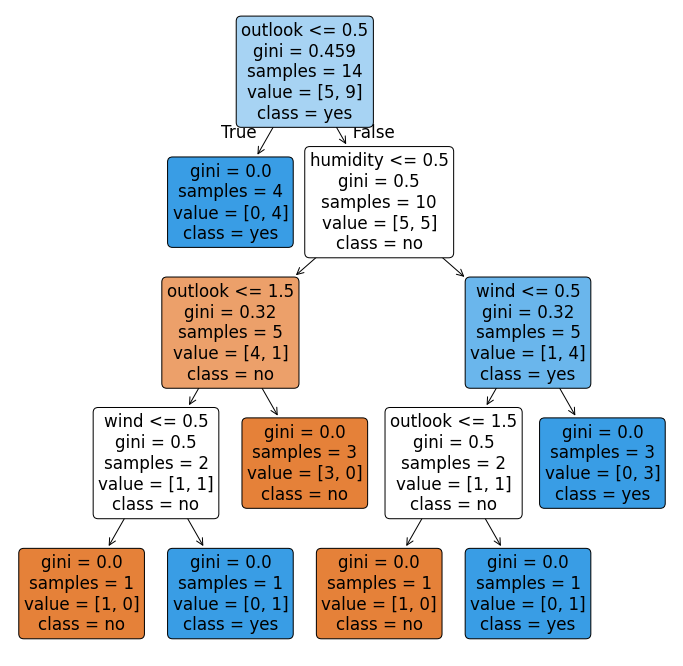

In [36]:
# Plot the decision tree
plt.figure(figsize=(12, 12))
plot_tree(dt_clf,
          feature_names = X_tennis.columns,
          class_names = ["no", "yes"],
          filled = True,
          rounded = True)
plt.show()

- Let's do some pruning.
- Tune the `max_depth` = $2$.

In [37]:
# Tree pruning.
dt_clf_pruned = DecisionTreeClassifier(max_depth=2, criterion="entropy")

# Fit the model.
dt_clf_pruned.fit(X_tennis, y_tennis)

DecisionTreeClassifier(criterion='entropy', max_depth=2)

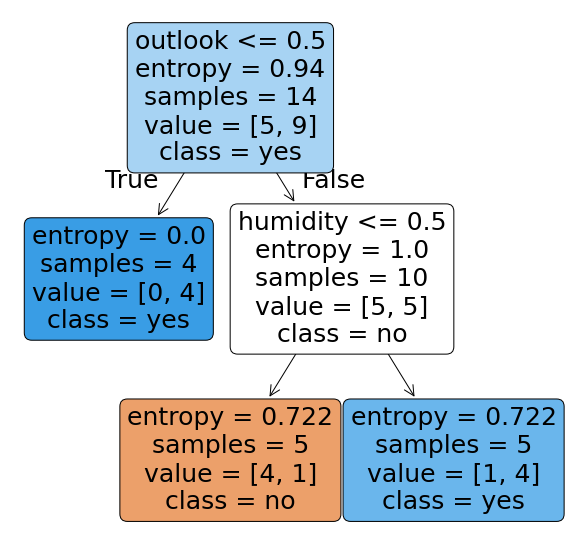

In [38]:
# Plot the pruned tree.
plt.figure(figsize=(10, 10))
plot_tree(dt_clf_pruned,
          feature_names = X_tennis.columns,
          class_names = ["no", "yes"],
          filled = True,
          rounded = True)
plt.show()